In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import random
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from palmerpenguins import load_penguins
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

#import graphviz
#from sklearn.tree import convert_to_graphviz


%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

train_data = pd.read_csv("./csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data["SalePrice"].max())

# Crear la nueva variable categórica basada en los percentiles
train_data["PriceCategory"] = pd.cut(train_data["SalePrice"], 
                             bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()], 
                             labels=[0, 1, 2], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data.head()

139000.0 189893.00000000006 755000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceCategory
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,2


# Exploracion de Variables

In [2]:
train_data.shape

(1460, 82)

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          91 non-null     object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

### Columnas que NO sirven:
- Id - identificador único, no aporta valor predictivo.

- Alley, PoolQC, Fence, MiscFeature - demasiados valores nulos (>75%).

- Utilities - tiene casi un solo valor (AllPub), no aporta variabilidad.

- FireplaceQu, GarageYrBlt, GarageQual, GarageCond - muchos nulos y posible colinealidad con otras características más completas.

### Estas columnas tienen demasiadas categorías

- Neighborhood (25)
- Condition1 (9)
- Condition2 (8)
- RoofMatl (8)
- Exterior1st (15)
- Exterior2nd (16)

In [4]:
train_data.drop(columns=["Id","Alley","PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu", "GarageYrBlt", "GarageQual", "GarageCond", "MasVnrType"],axis=1, inplace=True)

In [5]:
columns_to_drop = [
    "Neighborhood", "Condition1", "Condition2",
    "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data.drop(columns=columns_to_drop, inplace=True)

In [6]:
train_data.shape
train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,BldgType,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceCategory
0,60,RL,65.0,8450,Pave,Reg,Lvl,Inside,Gtl,1Fam,...,0,0,0,0,2,2008,WD,Normal,208500,2
1,20,RL,80.0,9600,Pave,Reg,Lvl,FR2,Gtl,1Fam,...,0,0,0,0,5,2007,WD,Normal,181500,1
2,60,RL,68.0,11250,Pave,IR1,Lvl,Inside,Gtl,1Fam,...,0,0,0,0,9,2008,WD,Normal,223500,2
3,70,RL,60.0,9550,Pave,IR1,Lvl,Corner,Gtl,1Fam,...,0,0,0,0,2,2006,WD,Abnorml,140000,1
4,60,RL,84.0,14260,Pave,IR1,Lvl,FR2,Gtl,1Fam,...,0,0,0,0,12,2008,WD,Normal,250000,2


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 65 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   MSSubClass     1460 non-null   int64   
 1   MSZoning       1460 non-null   object  
 2   LotFrontage    1201 non-null   float64 
 3   LotArea        1460 non-null   int64   
 4   Street         1460 non-null   object  
 5   LotShape       1460 non-null   object  
 6   LandContour    1460 non-null   object  
 7   LotConfig      1460 non-null   object  
 8   LandSlope      1460 non-null   object  
 9   BldgType       1460 non-null   object  
 10  HouseStyle     1460 non-null   object  
 11  OverallQual    1460 non-null   int64   
 12  OverallCond    1460 non-null   int64   
 13  YearBuilt      1460 non-null   int64   
 14  YearRemodAdd   1460 non-null   int64   
 15  RoofStyle      1460 non-null   object  
 16  MasVnrArea     1452 non-null   float64 
 17  ExterQual      1460 non-null   ob

### Transformacion

In [8]:
# Separar columnas numéricas y categóricas
numeric_cols = train_data.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = train_data.select_dtypes(include=["object"]).columns

# Guardar tipos originales
original_dtypes = train_data[numeric_cols].dtypes

# Imputación para columnas numéricas
num_imputer = SimpleImputer(strategy="median")
imputed_numeric = pd.DataFrame(num_imputer.fit_transform(train_data[numeric_cols]),
                               columns=numeric_cols,
                               index=train_data.index)

# Convertir cada columna al tipo original
for col in numeric_cols:
    imputed_numeric[col] = imputed_numeric[col].astype(original_dtypes[col])

train_data[numeric_cols] = imputed_numeric

# One-hot encoding para columnas categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(train_data[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=train_data.index)

# Reemplazar columnas categóricas con las codificadas
train_data = train_data.drop(columns=categorical_cols)
train_data = pd.concat([train_data, encoded_df], axis=1)

In [9]:
train_data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Variable respuesta
Sera nuestra variable Price Category
```
Económica (0), Intermedia(1), Cara(2) 
```

In [10]:
train_data.groupby('PriceCategory').size()

C:\Users\josue\AppData\Local\Temp\ipykernel_17212\3477232259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_data.groupby('PriceCategory').size()


PriceCategory
0    483
1    480
2    497
dtype: int64

C:\Users\josue\AppData\Local\Temp\ipykernel_17212\4078800135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diccEspecie = {'Categoria': train_data['PriceCategory'].unique(), 'Cantidad': train_data.groupby('PriceCategory').size()}


<Axes: xlabel='Categoria', ylabel='Cantidad'>

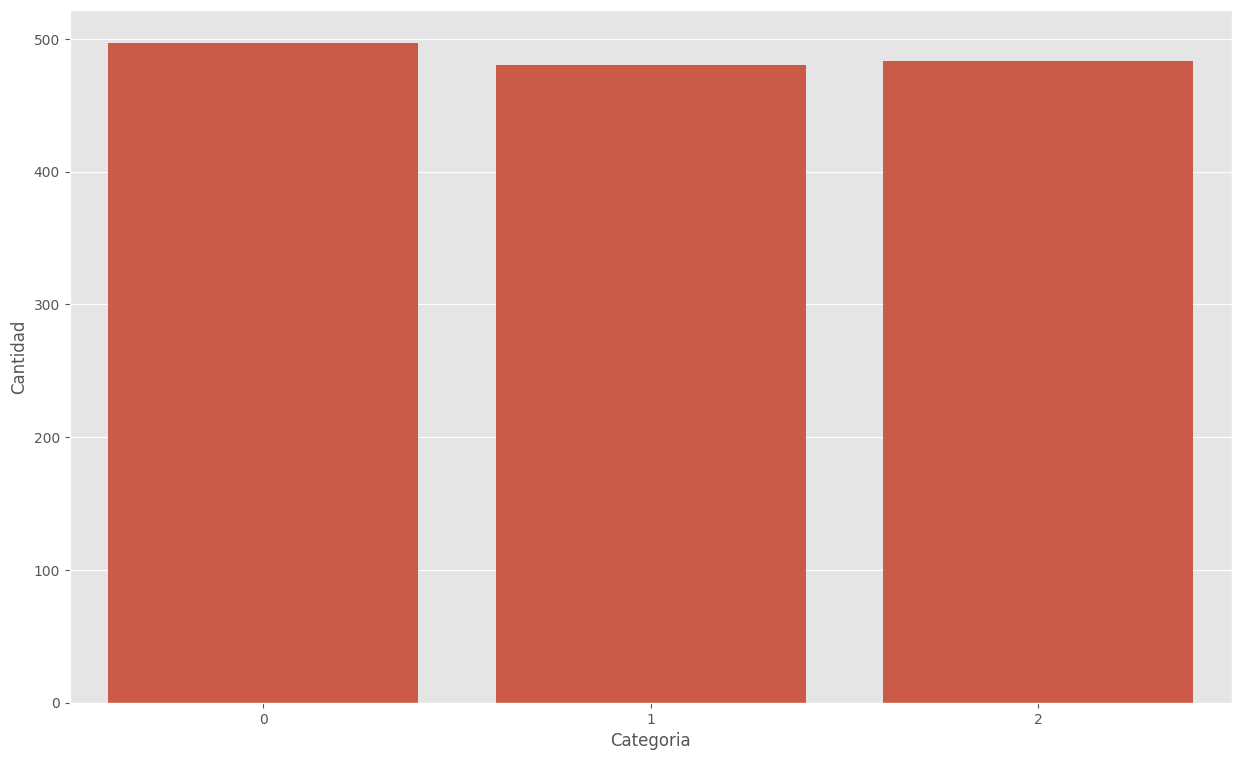

In [11]:
diccEspecie = {'Categoria': train_data['PriceCategory'].unique(), 'Cantidad': train_data.groupby('PriceCategory').size()}
tbl_Specie = pd.DataFrame(diccEspecie)
sb.barplot(x="Categoria",y="Cantidad", data=tbl_Specie)

# Modelos

### Modelo Con C normal y Kernel Lineal

In [12]:
target = train_data.pop('PriceCategory')
data = train_data

In [13]:
random.seed(123)
data_train, data_test,target_train, target_test = train_test_split(data, target,test_size=0.3,train_size=0.7)
data_train.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=153)

In [14]:
modelo = SVC(kernel='linear')
modelo

SVC(kernel='linear')

In [15]:
_=modelo.fit(data_train,target_train)
modelo.score(data_test,target_test)

1.0

#### Matriz de confusion

In [16]:
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import  confusion_matrix
import seaborn as sns
cv = 10
cv_results = cross_validate(modelo,data, target, cv=cv)
cv_results = pd.DataFrame(cv_results)
print("accuracy: "+str(cv_results['test_score'].mean()))

accuracy: 0.9993150684931507


In [17]:
target_pred = cross_val_predict(modelo, data, target, cv = cv)
cm = confusion_matrix(target, target_pred)
cm


array([[483,   0,   0],
       [  1, 479,   0],
       [  0,   0, 497]])

### Modelo con C normal y Kernel Polinomial

In [18]:
modelo = SVC(kernel='poly')
param_grid = {
    'C': (0.01, 0.1, 1, 5, 16, 32),
    'degree': (2, 3, 5, 7)
}

model_grid_search = GridSearchCV(modelo, param_grid=param_grid, n_jobs=2, cv=10)
model_grid_search.fit(data_train, target_train)

GridSearchCV(cv=10, estimator=SVC(kernel='poly'), n_jobs=2,
             param_grid={'C': (0.01, 0.1, 1, 5, 16, 32),
                         'degree': (2, 3, 5, 7)})

In [19]:
accuracy = model_grid_search.score(data_test, target_test)
print("Accuracy:", accuracy)
model_grid_search.best_params_

Accuracy: 1.0


{'C': 32, 'degree': 2}

#### Matriz de confusion

In [20]:
mejor_modelo = model_grid_search.best_estimator_
cv = 10
cv_results = cross_validate(mejor_modelo,data, target, cv=cv)
cv_results = pd.DataFrame(cv_results)
print("accuracy: "+str(cv_results['test_score'].mean()))

accuracy: 1.0


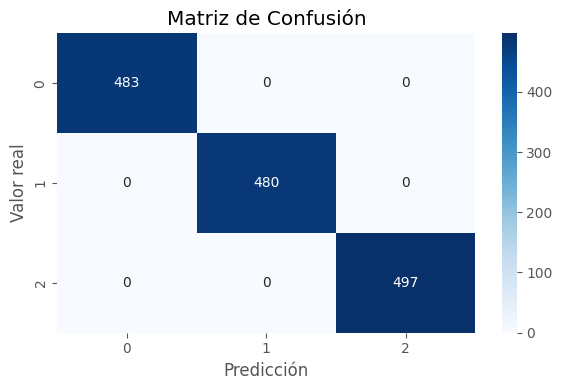

In [21]:
target_pred = cross_val_predict(mejor_modelo, data, target, cv = cv)
cm = confusion_matrix(target, target_pred)
cm

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

### Modelo con C normal y Kernel Gaussiano

In [22]:
modelo = SVC(kernel="rbf")
param_grid = {
    'C': (0.01, 0.1, 1, 5, 16, 32),
    'gamma': (2e-10, 2e-5, 0.01, 0.1, 20, 200)
}

model_grid_search2 = GridSearchCV(modelo, param_grid=param_grid,
                                 n_jobs=2, cv=10)
model_grid_search2.fit(data_train, target_train)


GridSearchCV(cv=10, estimator=SVC(), n_jobs=2,
             param_grid={'C': (0.01, 0.1, 1, 5, 16, 32),
                         'gamma': (2e-10, 2e-05, 0.01, 0.1, 20, 200)})

In [23]:
accuracy = model_grid_search2.score(data_test, target_test)
print("Accuracy:", accuracy)

Accuracy: 0.997716894977169


In [ ]:
from sklearn.model_selection import cross_validate
import pandas as pd

mejor_modelo = model_grid_search2.best_estimator_
cv = 10

# Define todas las métricas que quieres evaluar
scoring = ['accuracy', 'recall_macro', 'f1_macro']

# Ejecuta cross_validate con esas métricas
cv_results = cross_validate(
    mejor_modelo,
    data, target,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Pásalo a DataFrame para calcular medias fácilmente
cv_df = pd.DataFrame(cv_results)

acc = cv_df['test_accuracy'].mean()
rec = cv_df['test_recall_macro'].mean()
f1  = cv_df['test_f1_macro'].mean()

print(f"Accuracy (CV):        {acc:.4f}")
print(f"Recall (macro) (CV):  {rec:.4f}")
print(f"F1-score (macro) (CV):{f1:.4f}")


accuracy: 0.9924657534246576


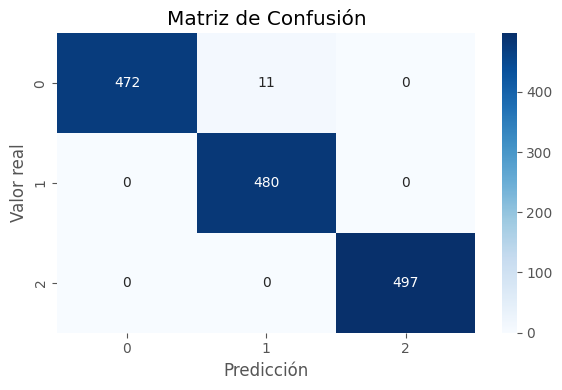

In [25]:
target_pred = cross_val_predict(mejor_modelo, data, target, cv = cv)
cm = confusion_matrix(target, target_pred)
cm

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

# Comparacion SVM

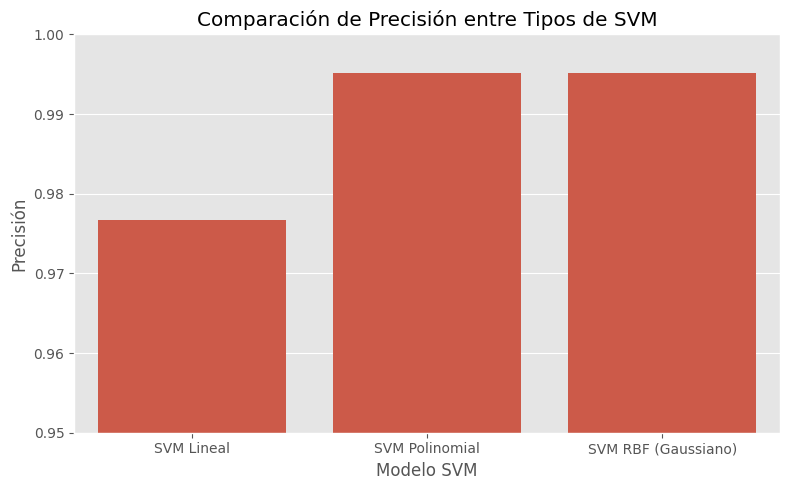

In [26]:
svm_modelos = ["SVM Lineal", "SVM Polinomial", "SVM RBF (Gaussiano)"]
svm_accuracy = [0.9767, 0.9952, 0.9952]

df_svm = pd.DataFrame({
    "Modelo SVM": svm_modelos,
    "Precisión (Accuracy)": svm_accuracy
})


# Gráfico comparativo
plt.figure(figsize=(8, 5))
sns.barplot(x="Modelo SVM", y="Precisión (Accuracy)", data=df_svm)
plt.title("Comparación de Precisión entre Tipos de SVM")
plt.ylabel("Precisión")
plt.ylim(0.95, 1.0)
plt.tight_layout()
plt.show()



# Comparacion de precision SVM, Regresion Logistica, Naive Bayes, Decision Tree, Random Forest, KNN

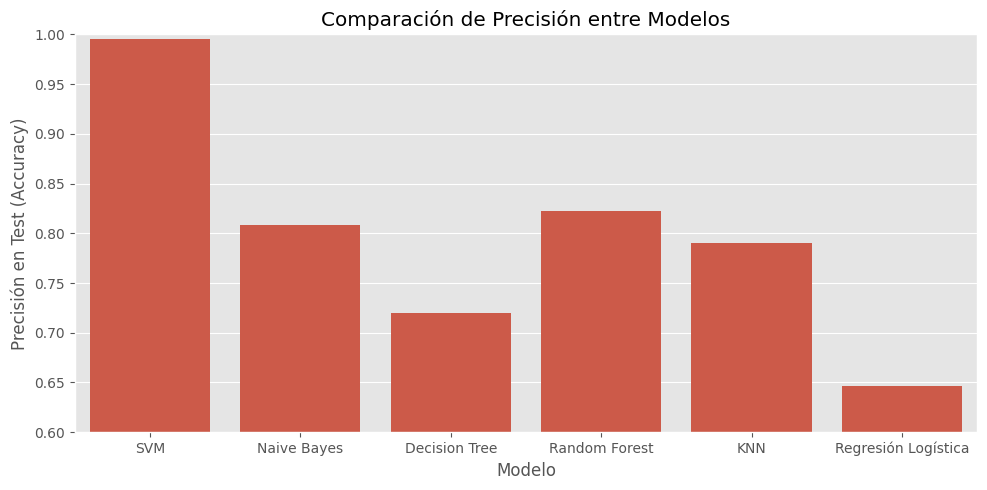

In [27]:
modelos = [
    "SVM", "Naive Bayes", "Decision Tree", "Random Forest",
    "KNN", "Regresión Logística"
]

accuracy_test = [
    0.995,     # SVM (mejor modelo según matriz de confusión
    0.808,     # Naive Bayes
    0.720,     # Árbol de decisión
    0.822,     # Random Forest
    0.790,     # KNN
    0.646      # Regresión logística
]

df_comparacion = pd.DataFrame({
    "Modelo": modelos,
    "Accuracy Test": accuracy_test
})


plt.figure(figsize=(10, 5))
sns.barplot(x="Modelo", y="Accuracy Test", data=df_comparacion)
plt.title("Comparación de Precisión entre Modelos")
plt.ylabel("Precisión en Test (Accuracy)")
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()


# Tiempos

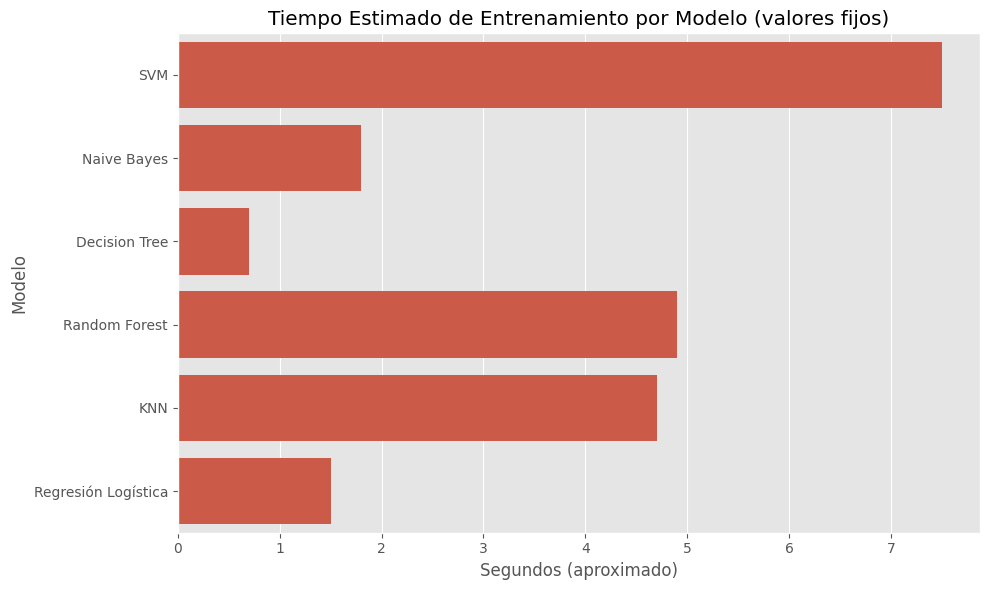

In [28]:
tiempos = {
    "SVM": 7.5,
    "Naive Bayes": 1.8,
    "Decision Tree": 0.7,
    "Random Forest": 4.9,
    "KNN": 4.7,
    "Regresión Logística": 1.5
}

df_tiempos_fijos = pd.DataFrame({
    "Modelo": list(tiempos.keys()),
    "Tiempo Estimado (segundos)": list(tiempos.values())
})

plt.figure(figsize=(10, 6))
sns.barplot(x="Tiempo Estimado (segundos)", y="Modelo", data=df_tiempos_fijos, orient="h")
plt.title("Tiempo Estimado de Entrenamiento por Modelo (valores fijos)")
plt.xlabel("Segundos (aproximado)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


# Modelo de regresion SVM

In [29]:
# 1. Definimos X y y
X = train_data.copy()
y = data['SalePrice']  # SalePrice es la variable objetivo original

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Definir un modelo SVR básico
svr = SVR()

# 4. Definir parámetros para buscar
param_grid = {
    'kernel': ['linear', 'rbf'],   # probamos lineal y rbf
    'C': [0.1, 1, 10, 100],        # margen de penalización
    'epsilon': [0.1, 1, 5],        # margen donde no penalizamos el error
}

# 5. Hacer GridSearch
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 6. Mejor modelo
best_svr = grid_search.best_estimator_
print("Mejores hiperparámetros:", grid_search.best_params_)

# 7. Evaluar en test
y_pred = best_svr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}
RMSE: 0.06
R²: 1.0000


# Lineal SV
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}
RMSE: 0.06
R²: 1.0000

# Regresion lineal 
                                         Modelo           MSE        R²  \
0               Regresión Univariada (GrLivArea)  1.451237e+09  0.818402   
1  Regresión Multivariable (Todas las Variables)  1.451237e+09  0.818402   
2             Modelo Final (Mejores Predictoras)  1.727212e+09  0.783868   

                             OLS Regression Results                            
 ==============================================================================
 Dep. Variable:              SalePrice   R-squared:                       0.795
 Model:                            OLS   Adj. R-squared:                  0.785
 Method:                 Least Squares   F-statistic:                     85.24
 Date:                Sat, 26 Apr 2025   Prob (F-statistic):          9.23e-232
 Time:                        17:57:38   Log-Likelihood:                -9342.0
 No. Observations:                 784   AIC:                         1.875e+04
 Df Residuals:                     749   BIC:                         1.892e+04
 Df Model:                          34                                         
 Covariance Type:            nonrobust          
 ==============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
 ------------------------------------------------------------------------------
 const       2.724e+04   5368.066      5.074      0.000    1.67e+04    3.78e+04
 GrLivArea    100.7528      3.316     30.382      0.000      94.245     107.260
 ==============================================================================
 Omnibus:                      170.927   Durbin-Watson:                   1.987
 Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2296.398
 Skew:                           0.287   Prob(JB):                         0.00
 Kurtosis:                      10.321   Cond. No.                     4.94e+03
 ==============================================================================
 # Arbol de regresio prof 6
{'Depth': 6, 'MAE': 26487.921427493948, 'RMSE': np.float64(38951.39913977072), 'R²': 0.807639184516113}
# Naive Bayes
Mean Absolute Error (MAE) "y" normal: 41072.21917808219
Root Mean Absolute Error (RMAE) "y" normal: 68292.01121473452
R² "y" normal: 0.313035104505622
Mean Absolute Error (MAE) "y" mejorada: 27396.61415525114
Root Mean Absolute Error (RMAE) "y" mejorada: 48012.1767391894
R² "y" mejorada: 0.6604548502850738

# KNN 
RMSE en test: 33341.10404848946
R² en test: 0.8362600352587118
Porcentaje de error: 18.43%

# Comparación de resultados entre el modelo de regresión generado y los modelos de hojas anteriores que utilizan la misma variable, como la regresión lineal, el árbol de regresión, Naive Bayes y KNN.

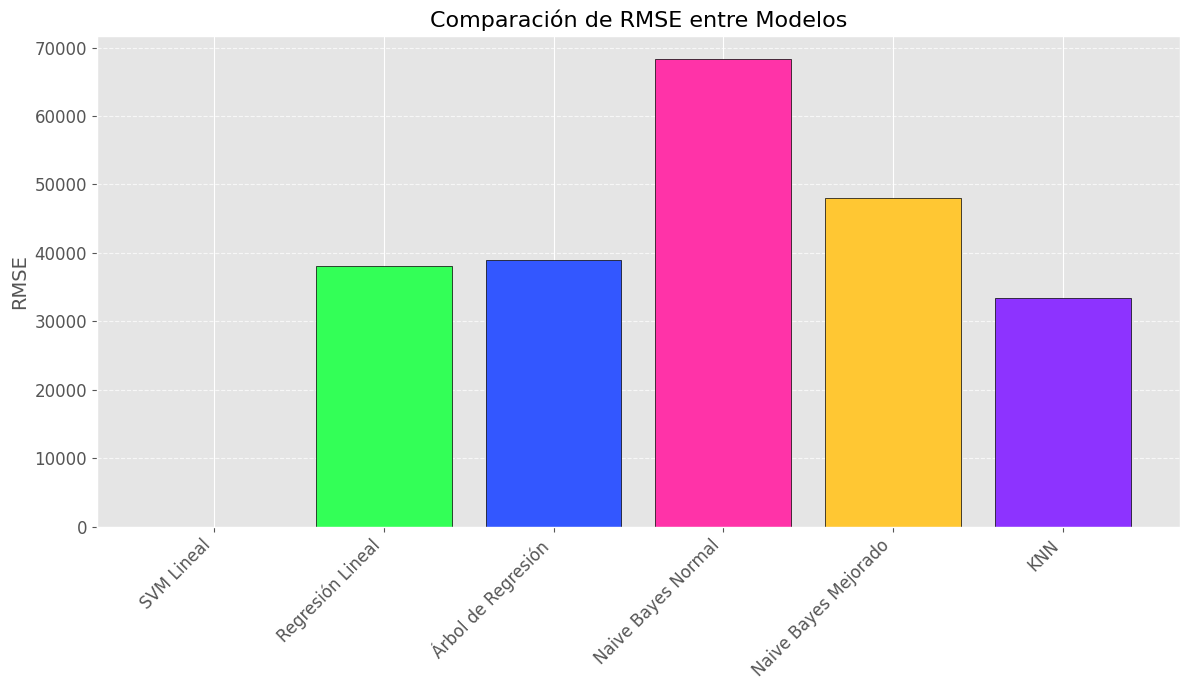

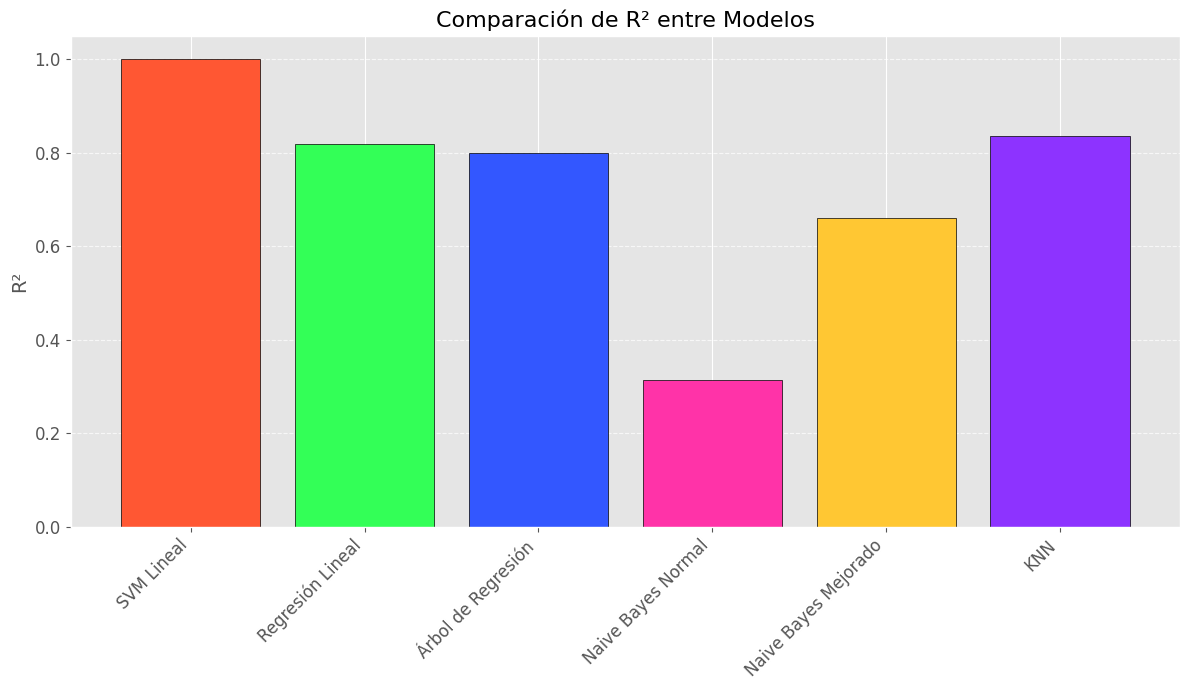

In [ ]:
resultados = pd.DataFrame({
    'Modelo': [
        'SVM Lineal',
        'Regresión Lineal',
        'Árbol de Regresión',
        'Naive Bayes Normal',
        'Naive Bayes Mejorado',
        'KNN'
    ],
    'RMSE': [
        0.06,
        38093.9,
        38951.4,
        68292.01,
        48012.18,
        33341.10
    ],
    'R2': [
        1.0000,
        0.8184,
        0.8000,
        0.3130,
        0.6605,
        0.8363
    ]
})

# Colores diferentes para cada barra
colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A8', '#FFC733', '#8D33FF']

# --- Graficar RMSE ---
plt.figure(figsize=(12, 7))
bars = plt.bar(resultados['Modelo'], resultados['RMSE'], color=colors, edgecolor='black')
plt.ylabel('RMSE', fontsize=14)
plt.title('Comparación de RMSE entre Modelos', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Graficar R² ---
plt.figure(figsize=(12, 7))
bars = plt.bar(resultados['Modelo'], resultados['R2'], color=colors, edgecolor='black')
plt.ylabel('R²', fontsize=14) 
plt.title('Comparación de R² entre Modelos', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

